In [ ]:
from features import save_features, get_features
from productdata import get_productdata
from marketdata import get_marketdata
from scipy.io import loadmat

product_data = get_productdata()
market_data = get_marketdata()
divs = loadmat(r"C:\Users\UGGROO\OneDrive - Van Lanschot Kempen\Documents\MSc Thesis\3. Repos\spil-utilities\spil-core\MainFiles\StoredMarketdataFiles\historicDiv_2025-07-12.mat")

features = get_features(product_data, market_data, divs)

save_features(features)

In [1]:
import pandas as pd

# Load DataFrame from pickle file
df = pd.read_pickle("feature_files/features_saved_on_2025-07-12.pkl")
df = df.dropna()

# Ensure Date is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort DataFrame by Date
df = df.sort_values(by='Date')

# Define target (y) and features (X)
y = df['Price']
X = df.drop(columns=['Price', 'Date'])  # Exclude Date from features

# Compute the split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Perform time-based train-test split
X_train_val, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train_val, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Print shapes to verify
print(f"X_train shape: {X_train_val.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train_val.shape}, y_test shape: {y_test.shape}")

X_train shape: (71871, 41), X_test shape: (17968, 41)
y_train shape: (71871,), y_test shape: (17968,)


In [2]:
import optuna
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit


def tune_elastic_net(trainval_X, trainval_y,
                     n_trials=50, random_state=42, n_splits=3):
    """
    Tune ElasticNet with Optuna using time-series cross-validation
    and feature standardisation.

    Parameters:
        trainval_X (pd.DataFrame): Features, ordered in time.
        trainval_y (pd.Series): Targets.
        n_trials (int): Number of Optuna trials.
        valid_size (float): (kept for API stability; not used with CV).
        random_state (int): Seed.
        n_splits (int): Folds for TimeSeriesSplit.

    Returns:
        best_model (Pipeline): StandardScaler + ElasticNet fitted on all data.
        best_params (dict): Best hyper-parameters found by Optuna.
    """
    X, y = trainval_X, trainval_y          
    cv = TimeSeriesSplit(n_splits=n_splits)

    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-4, 10, log=True)
        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("regressor", ElasticNet(alpha=alpha,
                                     l1_ratio=l1_ratio,
                                     random_state=random_state,
                                     max_iter=10000))
        ])

        mses = []
        for train_idx, valid_idx in cv.split(X):
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            preds = model.predict(X.iloc[valid_idx])
            mses.append(mean_squared_error(y.iloc[valid_idx], preds))

        return float(sum(mses) / len(mses))

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params

    # Final model: trained on all data
    best_model = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", ElasticNet(alpha=best_params["alpha"],
                                 l1_ratio=best_params["l1_ratio"],
                                 random_state=random_state,
                                 max_iter=10000))
    ])
    best_model.fit(X, y)

    return best_model, best_params

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_squared_error
import numpy as np
from scipy.stats import skew, kurtosis, jarque_bera


def evaluate_model_from_params(best_params, X_train_val, y_train_val,
                               X_test, y_test, random_state=42):
    """
    Evaluate ElasticNet model using given best parameters.

    Parameters:
    best_params (dict): Dictionary with 'alpha' and 'l1_ratio'.
    X_train_val (DataFrame): Training + validation features.
    y_train_val (Series): Training + validation targets.
    X_test (DataFrame): Test features.
    y_test (Series): Test targets.
    random_state (int): Random seed for reproducibility.

    Returns:
    dict: Dictionary with evaluation metrics.
    """
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", ElasticNet(
            alpha=best_params["alpha"],
            l1_ratio=best_params["l1_ratio"],
            random_state=random_state,
            max_iter=10000
        ))
    ])
    model.fit(X_train_val, y_train_val)

    pred_in_sample = model.predict(X_train_val)

    in_sample_metrics = {
        "Average Absolute Error": mean_absolute_error(y_train_val, pred_in_sample),
        "Maximum Absolute Error": np.max(np.abs(y_train_val - pred_in_sample)),
        "MSE": mean_squared_error(y_train_val, pred_in_sample),
        "Root Mean Squared Error": root_mean_squared_error(y_train_val, pred_in_sample),
        "Adjusted MAPE (%)": np.mean(np.abs((y_train_val - pred_in_sample) / (max(y_train_val) - min(y_train_val)))) * 100,
        "Out of Sample R2": r2_score(y_train_val, pred_in_sample)}


    predictions = model.predict(X_test)

    avg_abs_error = mean_absolute_error(y_test, predictions)
    max_abs_error = np.max(np.abs(y_test - predictions))
    rmse = root_mean_squared_error(y_test, predictions)

    epsilon = 1e-8
    mape = np.mean(np.abs((y_test - predictions) / (y_test + epsilon))) * 100
    adjusted_mape = np.mean(np.abs((y_test - predictions) / (max(y_test) - min(y_test)))) * 100

    errors = y_test - predictions
    mean_error = np.mean(errors)
    std_error = np.std(errors, ddof=1)
    skewness_error = skew(errors, bias=False)
    kurtosis_error = kurtosis(errors, fisher=False, bias=False)
    jb_stat, jb_p = jarque_bera(errors)
    r2 = r2_score(y_test, predictions)
    
    out_sample_metrics = {
        "Average Absolute Error": avg_abs_error,
        "Maximum Absolute Error": max_abs_error,
        "Root Mean Squared Error": rmse,
        "Mean Absolute Percentage Error (%)": mape,
        "Adjusted MAPE (%)": adjusted_mape,
        "Out of Sample R2": r2,
        "Mean Error": mean_error,
        "Std Dev Error": std_error,
        "Skewness": skewness_error,
        "Kurtosis": kurtosis_error,
        "Jarque-Bera Statistic": jb_stat,
        "Jarque-Bera p-value": jb_p,
        "Pricing Errors": errors
    }

    return in_sample_metrics, out_sample_metrics

In [5]:
import pickle
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet

def save_elastic_net(best_params, X, y, save_path="trained_elasticnet_model.pkl", random_state=42):
    """
    Trains an ElasticNet model on the full dataset and saves it to disk using pickle.

    Parameters:
    best_params (dict): Dictionary with 'alpha' and 'l1_ratio' for ElasticNet.
    X_full (DataFrame): Full feature set (e.g. training + test).
    y_full (Series): Full target set (aligned with X_full).
    save_path (str): Path to save the trained model.
    random_state (int): Seed for reproducibility.

    Returns:
    None
    """
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", ElasticNet(
            alpha=best_params["alpha"],
            l1_ratio=best_params["l1_ratio"],
            random_state=random_state,
            max_iter=10000
        ))
    ])
    model.fit(X, y)
    
    with open(save_path, "wb") as f:
        pickle.dump(model, f)
    
    print(f"Model trained on full data and saved to {save_path}")

In [ ]:
best_model, best_params = tune_elastic_net(X_train_val, y_train_val, n_trials=200)
is_metrics, oos_metrics = evaluate_model_from_params(best_params, X_train_val, y_train_val, X_test, y_test)

print("========== best params =============")
print(best_params)

print("========== in-sample =============")
print(is_metrics)

print("========== out-sample ============")
print(oos_metrics)

save_elastic_net(best_params, X, y, save_path="models/elasticnet_full_model_NOT_retuned.pkl")


[I 2025-07-16 21:21:53,775] A new study created in memory with name: no-name-7863def6-8fa2-4194-968b-804f0576e9c8
[I 2025-07-16 21:21:55,404] Trial 0 finished with value: 5.770232817422072 and parameters: {'alpha': 0.03640182789909453, 'l1_ratio': 0.7057405064748368}. Best is trial 0 with value: 5.770232817422072.
[I 2025-07-16 21:21:56,665] Trial 1 finished with value: 5.759927872433633 and parameters: {'alpha': 0.03535248598506041, 'l1_ratio': 0.43923997086716937}. Best is trial 1 with value: 5.759927872433633.
[I 2025-07-16 21:21:56,885] Trial 2 finished with value: 16.100876975380427 and parameters: {'alpha': 0.9986984880045651, 'l1_ratio': 0.547364381550278}. Best is trial 1 with value: 5.759927872433633.
[I 2025-07-16 21:21:58,915] Trial 3 finished with value: 5.728333654548398 and parameters: {'alpha': 0.015477531360351198, 'l1_ratio': 0.45446478405399693}. Best is trial 3 with value: 5.728333654548398.
[I 2025-07-16 21:21:59,146] Trial 4 finished with value: 18.711656372844853 

========== best params =============
{'alpha': 0.014140143483303648, 'l1_ratio': 0.011329793108000641}
========== in-sample =============
{'Average Absolute Error': 1.466509016647404, 'Maximum Absolute Error': 13.610473988417223, 'MSE': 3.9014321017217872, 'Root Mean Squared Error': 1.9752043189811497, 'Adjusted MAPE (%)': 4.285377868204631, 'Out of Sample R2': 0.8663281771575507}
========== out-sample ============
{'Average Absolute Error': 1.4580722982575345, 'Maximum Absolute Error': 8.239409968724091, 'Root Mean Squared Error': 1.945382536202073, 'Mean Absolute Percentage Error (%)': 4656882642.880793, 'Adjusted MAPE (%)': 5.764373802044355, 'Out of Sample R2': 0.8657829038485562, 'Mean Error': -0.18874551184340221, 'Std Dev Error': 1.936258504959029, 'Skewness': -0.5110462496711079, 'Kurtosis': 3.6089947985324247, 'Jarque-Bera Statistic': 1059.1840178553532, 'Jarque-Bera p-value': 1.0025657468630551e-230, 'Pricing Errors': 84675   -1.520019
73825    1.406876
69395   -0.101577
6347

In [5]:

best_params = {'alpha': 0.014140143483303648, 'l1_ratio': 0.011329793108000641}
is_metrics, oos_metrics = evaluate_model_from_params(best_params, X_train_val, y_train_val, X_test, y_test)

print("========== in-sample =============")
print(is_metrics)

print("========== out-sample ============")
print(oos_metrics)

oos_metrics['Pricing Errors'].to_csv("errors/en_errors_not_retuned.csv", index = False)

========== in-sample =============
{'Average Absolute Error': 1.466509016647404, 'Maximum Absolute Error': 13.610473988417223, 'MSE': 3.9014321017217872, 'Root Mean Squared Error': 1.9752043189811497, 'Adjusted MAPE (%)': 4.285377868204631, 'Out of Sample R2': 0.8663281771575507}
========== out-sample ============
{'Average Absolute Error': 1.4580722982575345, 'Maximum Absolute Error': 8.239409968724091, 'Root Mean Squared Error': 1.945382536202073, 'Mean Absolute Percentage Error (%)': 4656882642.880793, 'Adjusted MAPE (%)': 5.764373802044355, 'Out of Sample R2': 0.8657829038485562, 'Mean Error': -0.18874551184340221, 'Std Dev Error': 1.936258504959029, 'Skewness': -0.5110462496711079, 'Kurtosis': 3.6089947985324247, 'Jarque-Bera Statistic': 1059.1840178553532, 'Jarque-Bera p-value': 1.0025657468630551e-230, 'Pricing Errors': 84675   -1.520019
73825    1.406876
69395   -0.101577
63475   -2.231377
69394   -0.148442
           ...   
81351    0.210080
81352    0.219486
81353    0.189115

PermutationExplainer explainer: 17969it [26:25, 11.33it/s]                           
C:\Users\UGGROO\AppData\Local\Temp\ipykernel_6928\3905567932.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type = "bar", show= True)  # .iloc[:500]


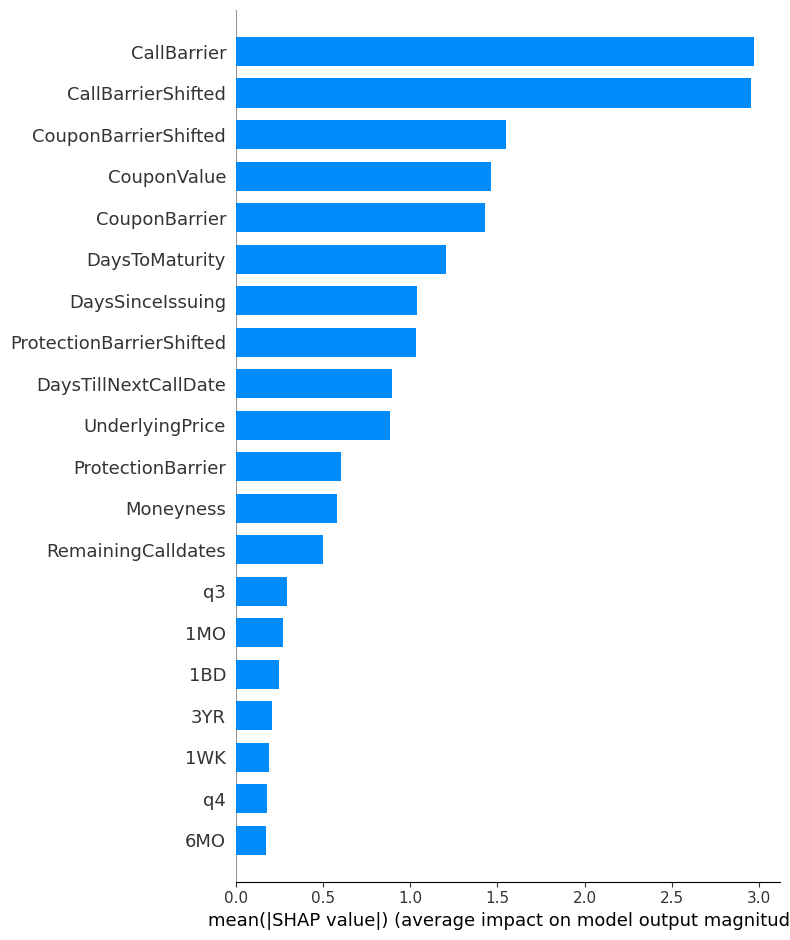

In [ ]:
import shap

model = pd.read_pickle("models/elasticnet_full_model_NOT_retuned.pkl")  

explainer = shap.Explainer(model.predict, X_train_val)  # background data
shap_values = explainer(X_test)                     # compute SHAP on test set
shap.summary_plot(shap_values, X_test, plot_type = "bar", show= True)  # .iloc[:500]




import itertools
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Which columns belong to which logical group?
yield_cols = ['1BD', '1WK', '1MO', '2MO', '6MO', '12MO',
              '2YR', '3YR', '4YR', '5YR', '7YR']
sabr_cols  = ['AlphaA', 'AlphaB', 'AlphaC',
              'RhoA', 'RhoB', 'RhoC',
              'NuB',  'NuC']
div_cols   = ['q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7']

group_dict = {
    'Yield curve' : yield_cols,
    'SABR parameters'   : sabr_cols,
    'Dividends'   : div_cols,
}

all_cols = list(X_test.columns)

# ----------------------------------------------------------------------
# 2. Aggregate SHAP values for the *defined* groups
group_importance = {}
for gname, gcols in group_dict.items():
    idx = [all_cols.index(c) for c in gcols]
    group_importance[gname] = np.abs(shap_values.values[:, idx]).mean()

# ----------------------------------------------------------------------
# 3. OPTIONAL: keep only features that are NOT in any group
#     (Skip this entire block if you do not want singletons at all.)
grouped_features = set(itertools.chain.from_iterable(group_dict.values()))

for c in all_cols:
    if c not in grouped_features:
        group_importance[c] = np.abs(
            shap_values.values[:, all_cols.index(c)]
        ).mean()

# ----------------------------------------------------------------------
# 4. Plot the result
group_importance = dict(
    sorted(group_importance.items(), key=lambda kv: kv[1], reverse=True)
)

plt.figure(figsize=(6, 4))
plt.barh(list(group_importance.keys()), list(group_importance.values()))
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP value|')
plt.title('Feature importance EN')
plt.show()

PermutationExplainer explainer: 301it [00:20,  7.15it/s]                         


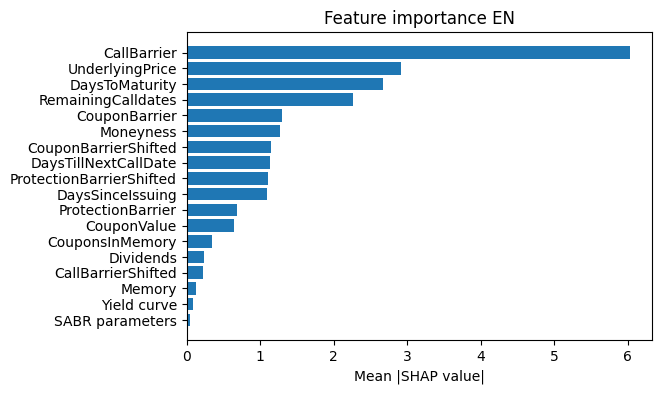

In [17]:
import pandas as pd
import shap

# model = pd.read_pickle("models/elasticnet_full_model_NOT_retuned.pkl")  
model = pd.read_pickle("models/elasticnet_full_model_retuned.pkl") 


# explainer = shap.Explainer(model.predict, X_train_val)  # background data
# shap_values = explainer(X_test)                     # compute SHAP on test set
# shap.summary_plot(shap_values, X_test, plot_type = "bar", show= True)  # .iloc[:500]

sim_df = pd.read_pickle(
    r"C:\Users\14gij\OneDrive\Documenten\1 Master\Thesis\thesis code\ML Training\feature_files\sim_features_large3_2025-07-21"
)
sim_df = sim_df.dropna()

# Define target (y) and features (X)
y_sim_test = sim_df['Price']
X_sim_test = sim_df.drop(columns=['Price', 'Date'])


explainer = shap.Explainer(model.predict, X)  # background data
shap_values = explainer(X_sim_test.iloc[:300])                     # compute SHAP on test set
#shap.summary_plot(shap_values, X_test, plot_type = "bar", show= True)  # .iloc[:500]


import itertools
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Which columns belong to which logical group?
yield_cols = ['1BD', '1WK', '1MO', '2MO', '6MO', '12MO',
              '2YR', '3YR', '4YR', '5YR', '7YR']
sabr_cols  = ['AlphaA', 'AlphaB', 'AlphaC',
              'RhoA', 'RhoB', 'RhoC',
              'NuB',  'NuC']
div_cols   = ['q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7']

group_dict = {
    'Yield curve' : yield_cols,
    'SABR parameters'   : sabr_cols,
    'Dividends'   : div_cols,
}

all_cols = list(X_test.columns)

# ----------------------------------------------------------------------
# 2. Aggregate SHAP values for the *defined* groups
group_importance = {}
for gname, gcols in group_dict.items():
    idx = [all_cols.index(c) for c in gcols]
    group_importance[gname] = np.abs(shap_values.values[:, idx]).mean()

# ----------------------------------------------------------------------
# 3. OPTIONAL: keep only features that are NOT in any group
#     (Skip this entire block if you do not want singletons at all.)
grouped_features = set(itertools.chain.from_iterable(group_dict.values()))

for c in all_cols:
    if c not in grouped_features:
        group_importance[c] = np.abs(
            shap_values.values[:, all_cols.index(c)]
        ).mean()

# ----------------------------------------------------------------------
# 4. Plot the result
group_importance = dict(
    sorted(group_importance.items(), key=lambda kv: kv[1], reverse=True)
)

plt.figure(figsize=(6, 4))
plt.barh(list(group_importance.keys()), list(group_importance.values()))
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP value|')
plt.title('Feature importance EN')
plt.show()

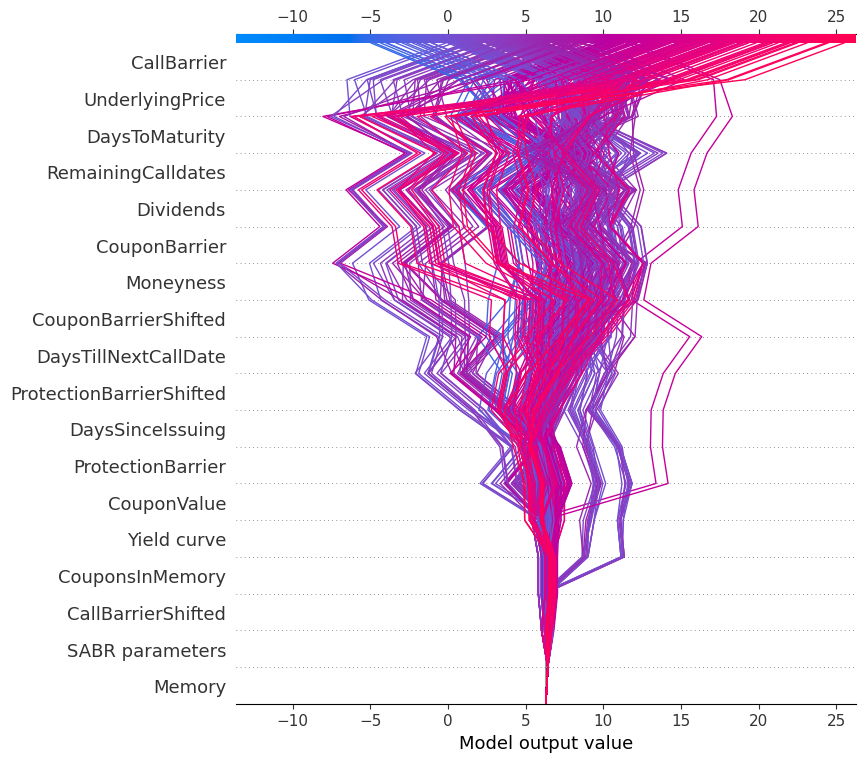

In [19]:
# --- SHAP decision plot with grouped features for a subsample of the first 200 observations ---
import numpy as np
import itertools

# 1) Build groups using your existing group_dict and add singletons
all_cols = list(X_sim_test.columns)
grouped_features = set(itertools.chain.from_iterable(group_dict.values()))

group_to_idx = {
    gname: [all_cols.index(c) for c in gcols if c in all_cols]
    for gname, gcols in group_dict.items()
}
for c in all_cols:
    if c not in grouped_features:
        group_to_idx[c] = [all_cols.index(c)]

group_names = list(group_to_idx.keys())

# 2) Aggregate SHAP values per group for ALL samples -> [n_samples x n_groups]
sv = shap_values.values  # shape: [n_samples x n_features]
group_sv_mat = np.column_stack([
    sv[:, idxs].sum(axis=1) if len(idxs) > 1 else sv[:, idxs[0]]
    for idxs in group_to_idx.values()
])

# 3) Order groups by global importance (mean |SHAP|) for cleaner plotting
order = np.argsort(np.mean(np.abs(group_sv_mat), axis=0))
group_sv_mat = group_sv_mat[:, order]
group_names_ordered = [group_names[j] for j in order]

# 4) Subsample the first 200 observations (avoid very large, slow plot)
idx = np.arange(min(500, group_sv_mat.shape[0]))

# 5) Use a scalar base value (average of base values across samples)
base_value_scalar = float(np.mean(shap_values.base_values))

# 6) Decision plot showing grouped paths for the subsample
shap.decision_plot(
    base_value=base_value_scalar,
    shap_values=group_sv_mat,  #[idx, :]
    feature_names=group_names_ordered,
    link="identity",
    show=True
)


In [5]:
best_params = {'alpha': 0.014140143483303648, 'l1_ratio': 0.011329793108000641}

df_test = X_test.copy()
df_test["target"] = y_test                    


mask_edge = (
    (df_test["DaysTillNextCallDate"] < 25)
    | ((df_test["DaysTillNextCallDate"] >= 340)
       & (df_test["DaysTillNextCallDate"] <= 365))
)

mask_other = ~mask_edge                       

# split the test frame
test_edge  = df_test[mask_edge].reset_index(drop=True)
test_other = df_test[mask_other].reset_index(drop=True)

# split into X / y
X_test_edge,  y_test_edge  = test_edge.drop(columns="target"),  test_edge["target"]
X_test_other, y_test_other = test_other.drop(columns="target"), test_other["target"]

print(f"Edge-of-year (<20  or  340–365) : {len(X_test_edge)} samples")
print(f"Other                            : {len(X_test_other)} samples")


is_metrics_edge,  oos_metrics_edge  = evaluate_model_from_params(
                                        best_params,
                                        X_train_val, y_train_val,
                                        X_test_edge,  y_test_edge)

is_metrics_other, oos_metrics_other = evaluate_model_from_params(
                                        best_params,
                                        X_train_val, y_train_val,
                                        X_test_other, y_test_other)

print("\n========== out-sample  (edge-of-year) ==========")
print(oos_metrics_edge)

print("\n========== out-sample  (other) ================")
print(oos_metrics_other)

Edge-of-year (<20  or  340–365) : 2669 samples
Other                            : 15299 samples

========== out-sample  (edge-of-year) ==========
{'Average Absolute Error': 1.823914437923733, 'Maximum Absolute Error': 7.374578546162958, 'Root Mean Squared Error': 2.306525336312395, 'Mean Absolute Percentage Error (%)': 6515864027.16488, 'Adjusted MAPE (%)': 10.279000824803024, 'Out of Sample R2': 0.7657791029528694, 'Mean Error': -0.4983450293388326, 'Std Dev Error': 2.2524680464044735, 'Skewness': 0.3818841447051585, 'Kurtosis': 3.12710866568265, 'Jarque-Bera Statistic': 66.52676084339963, 'Jarque-Bera p-value': 3.580118760587579e-15, 'Pricing Errors': 0      -0.101577
1      -0.148442
2      -0.467193
3      -0.632320
4      -0.553225
          ...   
2664    3.431222
2665    3.446749
2666    2.502954
2667    2.507554
2668   -0.771118
Name: target, Length: 2669, dtype: float64}

========== out-sample  (other) ================
{'Average Absolute Error': 1.3942489979915638, 'Maximum Ab

In [6]:
best_params = {'alpha': 0.014140143483303648, 'l1_ratio': 0.011329793108000641}

df_test = X_test.copy()
df_test["target"] = y_test


delta        = (df_test["Moneyness"] * 100 - df_test["CouponBarrier"]).abs()
diff_ratio   = delta / df_test["CouponBarrier"]

mask_within5pct  = diff_ratio <= 0.1     # ≤ 5 %
mask_outside5pct = ~mask_within5pct         # > 5 %


test_within5pct  = df_test[mask_within5pct].reset_index(drop=True)
test_outside5pct = df_test[mask_outside5pct].reset_index(drop=True)

X_test_within5pct,  y_test_within5pct  = (
    test_within5pct.drop(columns="target"),  test_within5pct["target"]
)
X_test_outside5pct, y_test_outside5pct = (
    test_outside5pct.drop(columns="target"), test_outside5pct["target"]
)

print(f"Within 5 % of barrier : {len(X_test_within5pct)} samples")
print(f"Outside that range    : {len(X_test_outside5pct)} samples")


is_met_within5pct,  oos_met_within5pct = evaluate_model_from_params(
    best_params,
    X_train_val, y_train_val,
    X_test_within5pct,  y_test_within5pct
)

is_met_outside5pct, oos_met_outside5pct = evaluate_model_from_params(
    best_params,
    X_train_val, y_train_val,
    X_test_outside5pct, y_test_outside5pct
)

print("\n========== out-sample  |Δ|/Barrier ≤ 5 % ==========")
print(oos_met_within5pct)

print("\n========== out-sample  |Δ|/Barrier > 5 % ==========")
print(oos_met_outside5pct)

Within 5 % of barrier : 816 samples
Outside that range    : 17152 samples

========== out-sample  |Δ|/Barrier ≤ 5 % ==========
{'Average Absolute Error': np.float64(2.9017150237498868), 'Maximum Absolute Error': np.float64(8.239409968724091), 'Root Mean Squared Error': np.float64(3.4621253245857906), 'Mean Absolute Percentage Error (%)': np.float64(870.1534374209995), 'Adjusted MAPE (%)': np.float64(28.05588546186183), 'Out of Sample R2': -1.3499860791512943, 'Mean Error': np.float64(-2.8990746963189276), 'Std Dev Error': np.float64(1.8936927852286676), 'Skewness': np.float64(-0.4267663287009048), 'Kurtosis': np.float64(2.1513266539602123), 'Jarque-Bera Statistic': np.float64(49.29135023090935), 'Jarque-Bera p-value': np.float64(1.9793349560040706e-11), 'Pricing Errors': 0     -2.231377
1     -2.243967
2     -2.216494
3     -1.604569
4     -2.178510
         ...   
811   -4.453874
812   -2.366986
813   -2.363680
814   -2.395604
815   -1.666767
Name: target, Length: 816, dtype: float64}

In [5]:
best_model_retuned, best_params_retuned = tune_elastic_net(X, y, n_trials=300)

print("========== best params retuned =============")
print(best_params_retuned)

save_elastic_net(best_params_retuned, X, y, save_path="models/elasticnet_full_model_retuned.pkl")

[I 2025-07-17 19:22:33,767] A new study created in memory with name: no-name-b83c1e2d-c90b-4d4b-8f3e-70d753bd8e9a
[I 2025-07-17 19:25:47,466] Trial 0 finished with value: 5.361055281533755 and parameters: {'alpha': 0.0005704725402486994, 'l1_ratio': 0.16754460957330486}. Best is trial 0 with value: 5.361055281533755.
[I 2025-07-17 19:25:48,812] Trial 1 finished with value: 6.019153752233 and parameters: {'alpha': 0.10308744416700073, 'l1_ratio': 0.46710506311836}. Best is trial 0 with value: 5.361055281533755.
[I 2025-07-17 19:25:54,549] Trial 2 finished with value: 5.313246838933996 and parameters: {'alpha': 0.01273818944993772, 'l1_ratio': 0.4773695685558419}. Best is trial 2 with value: 5.313246838933996.
[I 2025-07-17 19:25:55,218] Trial 3 finished with value: 8.193377532746073 and parameters: {'alpha': 0.3212060230602495, 'l1_ratio': 0.8492038518741774}. Best is trial 2 with value: 5.313246838933996.
[I 2025-07-17 19:25:55,953] Trial 4 finished with value: 13.541563116131556 and p

========== best params retuned =============
{'alpha': 0.0029056057414505324, 'l1_ratio': 0.972119001095183}
Model trained on full data and saved to models/elasticnet_full_model_retuned.pkl


In [10]:
import pandas as pd

best_params_experiment = {'alpha': 0.0029056057414505324, 'l1_ratio': 0.972119001095183}

sim_train = pd.read_pickle(
    "C:/Users/UGGROO/OneDrive - Van Lanschot Kempen/Documents/MSc Thesis/3. Repos/thesis code/ML Training/feature_files/sim_features_large5_2025-07-22"
)
sim_train = sim_train.dropna()

y_sim_train = sim_train['Price']
X_sim_train = sim_train.drop(columns=['Price', 'Date']) 

save_elastic_net(best_params_experiment, X_sim_train, y_sim_train, save_path="models/elasticnet_full_model_experiment_large4.pkl")

Model trained on full data and saved to models/elasticnet_full_model_experiment_large4.pkl


c:\Users\UGGROO\AppData\Local\anaconda3\envs\thesis\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.969e+01, tolerance: 9.125e+00
  model = cd_fast.enet_coordinate_descent(


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from scipy.stats import skew, kurtosis, jarque_bera   

sim_df = pd.read_pickle(
    r"C:\Users\14gij\OneDrive\Documenten\1 Master\Thesis\thesis code\ML Training\feature_files\sim_features_large3_2025-07-21"
)
#sim_df = sim_df[sim_df['CouponsInMemory']<=1]
#sim_df = sim_df[sim_df['CallBarrier']==1000]

y_sim_test = sim_df['Price']
X_sim_test = sim_df.drop(columns=['Price', 'Date'])  

model = pd.read_pickle("models/elasticnet_full_model_retuned.pkl")  

predictions = model.predict(X_sim_test)

avg_abs_error = mean_absolute_error(y_sim_test, predictions)
max_abs_error = np.max(np.abs(y_sim_test - predictions))
rmse = root_mean_squared_error(y_sim_test, predictions)

epsilon = 1e-8
mape = np.mean(np.abs((y_sim_test - predictions) / (y_sim_test + epsilon))) * 100
adjusted_mape = np.mean(np.abs((y_sim_test - predictions) / (max(y_sim_test) - min(y_sim_test)))) * 100
r2 = r2_score(y_sim_test, predictions)

errors = y_sim_test - predictions
errors.to_csv("errors/en_errors_retuned.csv", index = False)

mean_error     = np.mean(errors)
std_error      = np.std(errors, ddof=1)                      
skewness_error = skew(errors, bias=False)
kurtosis_error = kurtosis(errors, fisher=False, bias=False)   
jb_stat, jb_p  = jarque_bera(errors)


print({
    "Average Absolute Error":             avg_abs_error,
    "Maximum Absolute Error":             max_abs_error,
    "Root Mean Squared Error":            rmse,
    "Mean Absolute Percentage Error (%)": mape,
    "Adjusted MAPE (%)":                  adjusted_mape,
    "Out of Sample R2":                   r2,
    "Mean Error":                         mean_error,
    "Std Dev Error":                      std_error,
    "Skewness":                           skewness_error,
    "Kurtosis":                           kurtosis_error,
    "Jarque-Bera Statistic":              jb_stat,
    "Jarque-Bera p-value":                jb_p
})

{'Average Absolute Error': 4.630093656886037, 'Maximum Absolute Error': 24.730021151275224, 'Root Mean Squared Error': 5.912997829088171, 'Mean Absolute Percentage Error (%)': 81.52702547405943, 'Adjusted MAPE (%)': 30.69736575418264, 'Out of Sample R2': -1.451805418236464, 'Mean Error': -4.443483185703453, 'Std Dev Error': 3.902725202055467, 'Skewness': -1.039681757126823, 'Kurtosis': 4.829693104147533, 'Jarque-Bera Statistic': 394.1615636465124, 'Jarque-Bera p-value': 2.5639170179272088e-86}


In [ ]:
# # import optuna
# # from sklearn.linear_model import ElasticNet
# # from sklearn.pipeline import Pipeline
# # from sklearn.preprocessing import StandardScaler
# # from sklearn.metrics import root_mean_squared_error

# # def tune_elastic_net(trainval_X, trainval_y, n_trials=50, valid_size=0.2, random_state=42):
# #     """
# #     Tune ElasticNet with Optuna using a time-aware split and feature standardization.

# #     Parameters:
# #         trainval_X (array-like): Features, ordered in time if time series.
# #         trainval_y (array-like): Targets.
# #         n_trials (int): Number of Optuna trials.
# #         valid_size (float): Fraction of data for validation.
# #         random_state (int): Seed.

# #     Returns:
# #         best_model (Pipeline): Trained Pipeline with StandardScaler + ElasticNet.
# #         best_params (dict): Best hyperparameters found by Optuna.
# #     """
# #     n_samples = len(trainval_X)
# #     split_index = int(n_samples * (1 - valid_size))

# #     X_train, X_valid = trainval_X[:split_index], trainval_X[split_index:]
# #     y_train, y_valid = trainval_y[:split_index], trainval_y[split_index:]

# #     def objective(trial):
# #         alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
# #         l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

# #         model = Pipeline([
# #             ("scaler", StandardScaler()),
# #             ("regressor", ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
# #                                      random_state=random_state, max_iter=10000))
# #         ])

# #         model.fit(X_train, y_train)
# #         preds = model.predict(X_valid)
# #         rmse = root_mean_squared_error(y_valid, preds)
# #         return rmse

# #     study = optuna.create_study(direction="minimize")
# #     study.optimize(objective, n_trials=n_trials)

# #     best_params = study.best_params

# #     # Final model: trained on all data
# #     best_model = Pipeline([
# #         ("scaler", StandardScaler()),
# #         ("regressor", ElasticNet(
# #             alpha=best_params["alpha"],
# #             l1_ratio=best_params["l1_ratio"],
# #             random_state=random_state,
# #             max_iter=10000
# #         ))
# #     ])
# #     best_model.fit(trainval_X, trainval_y)

# #     return best_model, best_params

# sim_df = pd.read_pickle("C:/Users/UGGROO/OneDrive - Van Lanschot Kempen/Documents/MSc Thesis/3. Repos/thesis code/ML Training/feature_files/sim_features_2025-06-11")

# # Define target (y) and features (X)
# y_sim_test = sim_df['Price']
# X_sim_test = sim_df.drop(columns=['Price', 'Date'])  # Exclude Date from features

# model = pd.read_pickle("models/elasticnet_full_model.pkl")

# predictions = model.predict(X_sim_test)

# avg_abs_error = mean_absolute_error(y_sim_test, predictions)
# max_abs_error = np.max(np.abs(y_sim_test - predictions))
# rmse = root_mean_squared_error(y_sim_test, predictions)

# epsilon = 1e-8
# mape = np.mean(np.abs((y_sim_test - predictions) / (y_sim_test + epsilon))) * 100
# y_test_safe = np.where(np.abs(y_sim_test) < 1e-2, 1e-2, y_sim_test)
# adjusted_mape = np.mean(np.abs((y_sim_test - predictions) / y_test_safe)) * 100

# print({
#         "Average Absolute Error": avg_abs_error,
#         "Maximum Absolute Error": max_abs_error,
#         "Root Mean Squared Error": rmse,
#         "Mean Absolute Percentage Error (%)": mape,
#         "Adjusted MAPE (%)": adjusted_mape
#     })

# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import ElasticNet
# from sklearn.metrics import mean_absolute_error, root_mean_squared_error
# import numpy as np

# def evaluate_model_from_params(best_params, X_train_val, y_train_val, X_test, y_test, random_state=42):
#     """
#     Evaluate ElasticNet model using given best parameters.

#     Parameters:
#     best_params (dict): Dictionary with 'alpha' and 'l1_ratio'.
#     X_train_val (DataFrame): Training + validation features.
#     y_train_val (Series): Training + validation targets.
#     X_test (DataFrame): Test features.
#     y_test (Series): Test targets.
#     random_state (int): Random seed for reproducibility.

#     Returns:
#     dict: Dictionary with evaluation metrics.
#     """
#     # Rebuild and train model on full train+validation set
#     model = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regressor", ElasticNet(
#             alpha=best_params["alpha"],
#             l1_ratio=best_params["l1_ratio"],
#             random_state=random_state,
#             max_iter=10000
#         ))
#     ])
#     model.fit(X_train_val, y_train_val)

#     # Predict on test set
#     predictions = model.predict(X_test)

#     # Compute basic metrics
#     avg_abs_error = mean_absolute_error(y_test, predictions)
#     max_abs_error = np.max(np.abs(y_test - predictions))
#     rmse = root_mean_squared_error(y_test, predictions)

#     # Mean Absolute Percentage Error (MAPE)
#     # Avoid division by zero by adding epsilon or filtering
#     epsilon = 1e-8
#     # mape = np.mean(np.abs((y_test - predictions) / (np.max(y_test) - np.min(y_test)))) *100
#     mape = np.mean(np.abs((y_test - predictions) / (y_test))) * 100

#     # Adjusted MAPE: clip small true values to avoid huge errors
#     y_test_safe = np.where(np.abs(y_test) < 1e-1, 1e-1, y_test)
#     adjusted_mape = np.mean(np.abs((y_test - predictions) / y_test_safe)) * 100

#     return {
#         "Average Absolute Error": avg_abs_error,
#         "Maximum Absolute Error": max_abs_error,
#         "Root Mean Squared Error": rmse,
#         "Mean Absolute Percentage Error (%)": mape,
#         "Adjusted MAPE (%)": adjusted_mape
#     }

# import optuna
# from sklearn.linear_model import ElasticNet
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import mean_squared_error

# def tune_elastic_net(trainval_X, trainval_y, n_trials=50, valid_size=0.2, random_state=42):
#     """
#     Tune ElasticNet with Optuna using a time-aware split and feature standardization.

#     Parameters:
#         trainval_X (array-like): Features, ordered in time if time series.
#         trainval_y (array-like): Targets.
#         n_trials (int): Number of Optuna trials.
#         valid_size (float): Fraction of data for validation.
#         random_state (int): Seed.

#     Returns:
#         best_model (Pipeline): Trained Pipeline with StandardScaler + ElasticNet.
#         best_params (dict): Best hyperparameters found by Optuna.
#     """
#     n_samples = len(trainval_X)
#     split_index = int(n_samples * (1 - valid_size))

#     X_train, X_valid = trainval_X[:split_index], trainval_X[split_index:]
#     y_train, y_valid = trainval_y[:split_index], trainval_y[split_index:]

#     def objective(trial):
#         alpha = trial.suggest_float("alpha", 1e-4, 10, log=True)
#         l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1)

#         model = Pipeline([
#             ("scaler", StandardScaler()),
#             ("regressor", ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
#                                      random_state=random_state, max_iter=10000))
#         ])

#         model.fit(X_train, y_train)
#         preds = model.predict(X_valid)
#         mse = mean_squared_error(y_valid, preds)
#         return mse

#     study = optuna.create_study(direction="minimize")
#     study.optimize(objective, n_trials=n_trials)

#     best_params = study.best_params

#     # Final model: trained on all data
#     best_model = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regressor", ElasticNet(
#             alpha=best_params["alpha"],
#             l1_ratio=best_params["l1_ratio"],
#             random_state=random_state,
#             max_iter=10000
#         ))
#     ])
#     best_model.fit(trainval_X, trainval_y)

#     return best_model, best_params